# Phase 2: Data Preprocessing & Data Spliting and Scaling
**Project:** boston_housing_prediction  
**Goal:** Clean, , explore, and split dataset into relational dimension & fact tables for model integration and interactive Dashboards.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

data = pd.read_csv('housing.csv')


data.head()

,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0


Step 1 : Data Cleaning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

data = pd.read_csv('housing.csv')


print("Data Types:\n", data.dtypes)
print("-" * 50)
print("Data Shape:\n", data.shape)
print("-" * 50)
print("Basic Statistics:\n", data.describe())
print("-" * 50)


missing_values = data['MEDV'].isnull().sum()
print(f"Missing values in MEDV: {missing_values}")

Q1 = data['MEDV'].quantile(0.25)
Q3 = data['MEDV'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['MEDV'] < lower_bound) | (data['MEDV'] > upper_bound)]
print(f"Number of outliers in MEDV: {len(outliers)}")

Data Types:
 RM         float64
LSTAT      float64
PTRATIO    float64
MEDV       float64
dtype: object
--------------------------------------------------
Data Shape:
 (489, 4)
--------------------------------------------------
Basic Statistics:
                RM       LSTAT     PTRATIO          MEDV
count  489.000000  489.000000  489.000000  4.890000e+02
mean     6.240288   12.939632   18.516564  4.543429e+05
std      0.643650    7.081990    2.111268  1.653403e+05
min      3.561000    1.980000   12.600000  1.050000e+05
25%      5.880000    7.370000   17.400000  3.507000e+05
50%      6.185000   11.690000   19.100000  4.389000e+05
75%      6.575000   17.120000   20.200000  5.187000e+05
max      8.398000   37.970000   22.000000  1.024800e+06
--------------------------------------------------
Missing values in MEDV: 0
Number of outliers in MEDV: 22


In [4]:
import numpy as np

# handling outliers
Q1 = data['MEDV'].quantile(0.25)
Q3 = data['MEDV'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data['MEDV'] = np.clip(data['MEDV'], lower_bound, upper_bound)

step 2 : Separating Features & Target

In [22]:
X = data[['RM', 'LSTAT', 'PTRATIO']]
y = data['MEDV']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (489, 3)
Target shape: (489,)


Step 3 :Train / Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = X_train.copy()
X_test = X_test.copy()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (391, 3)
X_test shape: (98, 3)


Step 4 : Handling Outliers & Feature Engineering

In [ ]:

Q1_train = y_train.quantile(0.25)
Q3_train = y_train.quantile(0.75)
IQR_train = Q3_train - Q1_train

lower_b = Q1_train - 1.5 * IQR_train
upper_b = Q3_train + 1.5 * IQR_train

y_train = np.clip(y_train, lower_b, upper_b)


X_train['RM_LSTAT_ratio'] = X_train['RM'] / (X_train['LSTAT'] + 1e-5)
X_test['RM_LSTAT_ratio'] = X_test['RM'] / (X_test['LSTAT'] + 1e-5)

X_train.head()

,RM,LSTAT,PTRATIO,RM_LSTAT_ratio
325,5.869,9.80,20.2,0.598877
140,6.174,24.16,21.2,0.255546
433,6.749,17.44,20.2,0.386984
416,6.436,16.22,20.2,0.396794
487,6.794,6.48,21.0,1.048455


step 5 : Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


joblib.dump(scaler, 'scaler.joblib')
print("Scaler saved successfully as 'scaler.joblib'")


Scaler saved successfully as 'scaler.joblib'


In [26]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (391, 4)
X_test shape:  (98, 4)
y_train shape: (391,)
y_test shape:  (98,)


Step 6 : EDA Exploration 

**Univariate Analysis**


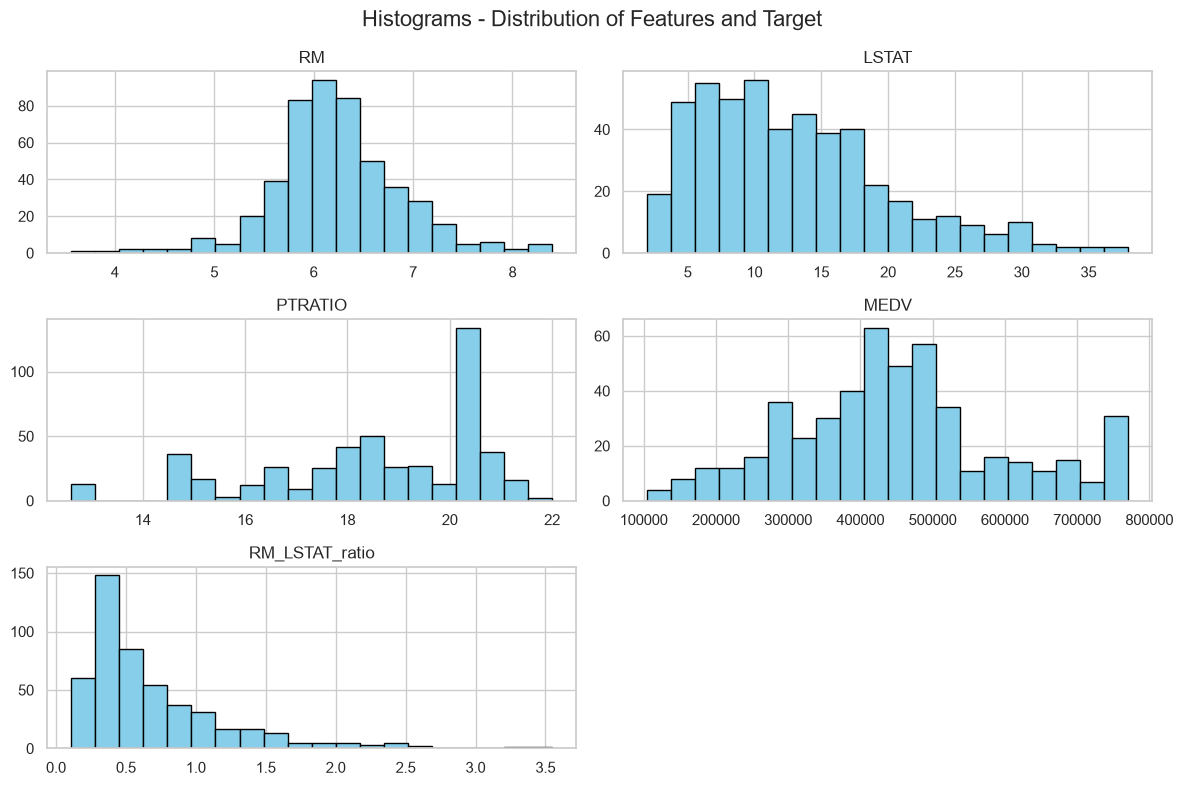

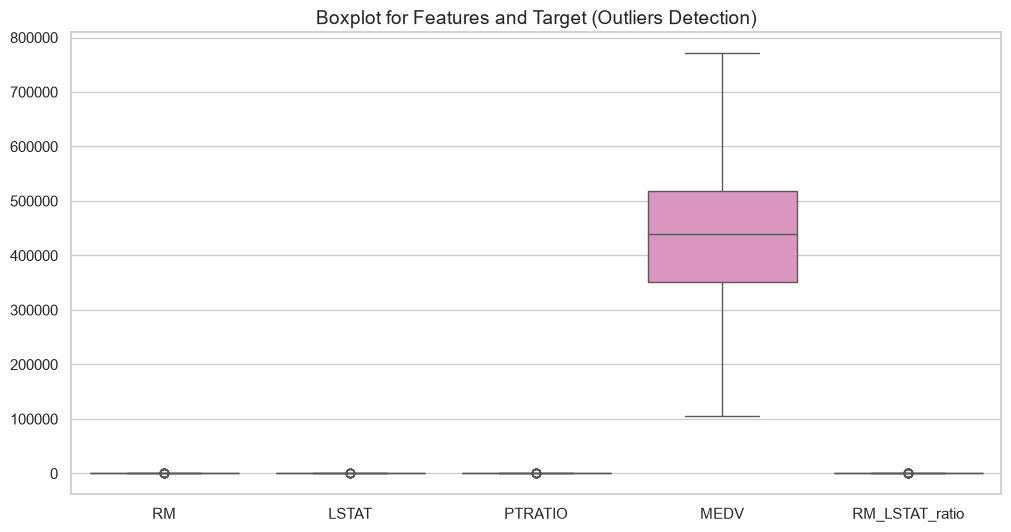

In [ ]:

data.hist(bins=20, figsize=(12, 8), color='skyblue', edgecolor='black')
plt.suptitle('Histograms - Distribution of Features and Target', fontsize=16)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
sns.boxplot(data=data, palette="Set2")
plt.title('Boxplot for Features and Target (Outliers Detection)', fontsize=14)
plt.show()

**Bivariate Analysis - Regplots**

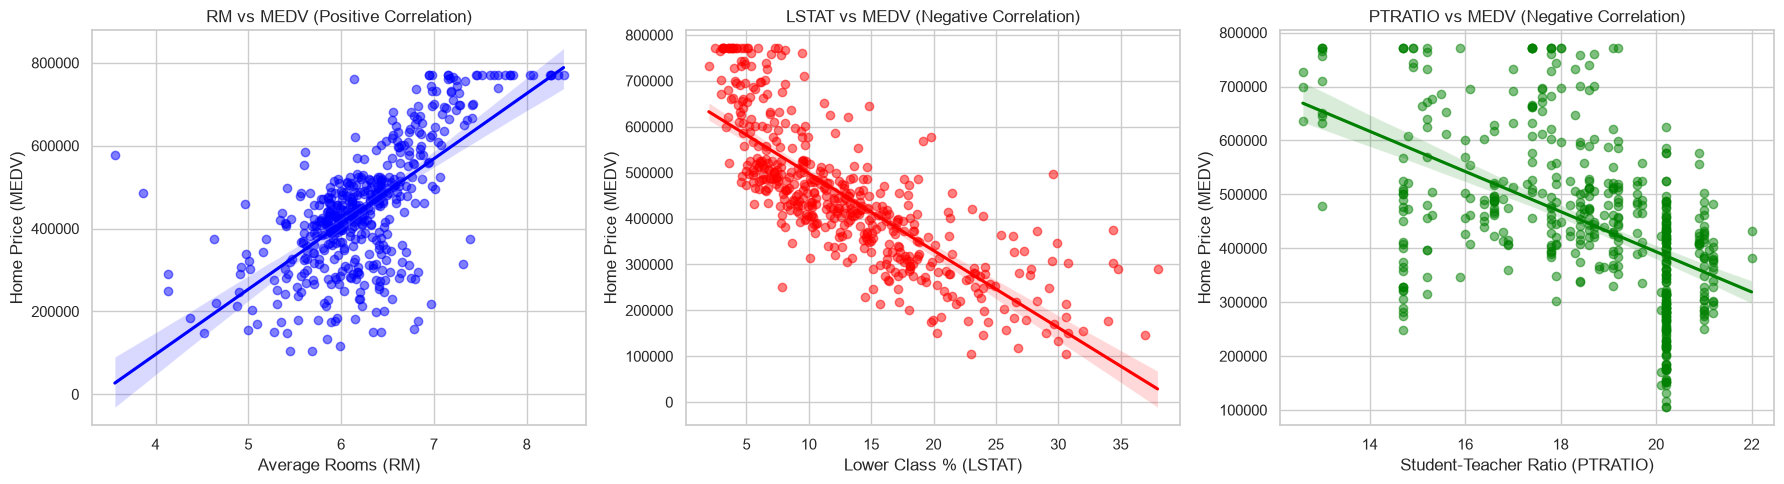

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. RM vs MEDV
sns.regplot(x=data['RM'], y=data['MEDV'], ax=axes[0], color='blue', scatter_kws={'alpha':0.5})
axes[0].set_title('RM vs MEDV (Positive Correlation)')
axes[0].set_xlabel('Average Rooms (RM)')
axes[0].set_ylabel('Home Price (MEDV)')

# 2. LSTAT vs MEDV
sns.regplot(x=data['LSTAT'], y=data['MEDV'], ax=axes[1], color='red', scatter_kws={'alpha':0.5})
axes[1].set_title('LSTAT vs MEDV (Negative Correlation)')
axes[1].set_xlabel('Lower Class % (LSTAT)')
axes[1].set_ylabel('Home Price (MEDV)')

# 3. PTRATIO vs MEDV
sns.regplot(x=data['PTRATIO'], y=data['MEDV'], ax=axes[2], color='green', scatter_kws={'alpha':0.5})
axes[2].set_title('PTRATIO vs MEDV (Negative Correlation)')
axes[2].set_xlabel('Student-Teacher Ratio (PTRATIO)')
axes[2].set_ylabel('Home Price (MEDV)')

plt.tight_layout()
plt.show()

**Correlation Matrix**

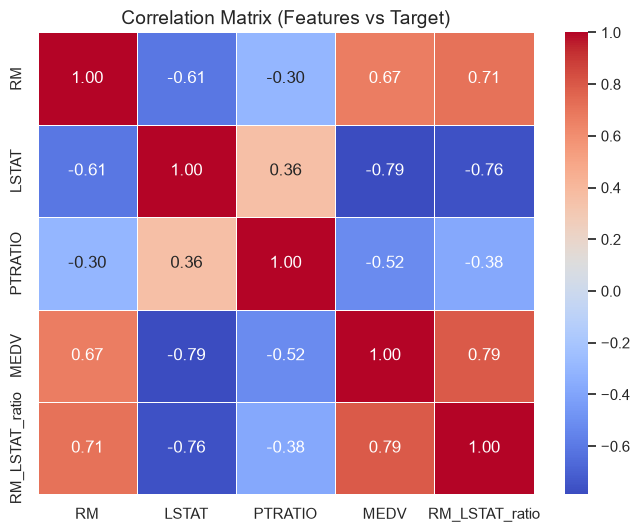

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (Features vs Target)', fontsize=14)
plt.show()

step 7 : Relational / Dimension & Fact Tables

In [ ]:

dim_property = data[['RM', 'LSTAT', 'PTRATIO']].copy()
dim_property['Property_ID'] = range(1, len(dim_property) + 1)


fact_housing = data[['MEDV']].copy()
fact_housing['Property_ID'] = dim_property['Property_ID']
fact_housing['RM_LSTAT_ratio'] = dim_property['RM'] / (dim_property['LSTAT'] + 1e-5)


dim_property.to_csv('dim_property.csv', index=False)
fact_housing.to_csv('fact_housing_prices.csv', index=False)

print("Dimension and Fact tables exported ")

Dimension and Fact tables exported successfully!


In [29]:
data.to_csv('boston_housing_cleaned.csv', index=False)

print("boston_housing_cleaned.csv done")

boston_housing_cleaned.csv done
